In [15]:
import pandas as pd
import numpy as np


In [16]:
df = pd.read_csv(r'E:\Rnw\algorithms\Superviced learning\practical exam\creditcard.csv')

In [17]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
df.shape

(284807, 31)

In [28]:
from sklearn.model_selection import train_test_split

sample_proportion = 50000 / len(df)

df_sampled, _ = train_test_split(
    df, 
    train_size=sample_proportion, 
    stratify=df['Class'], 
    random_state=42
)

print("Original Dataset Class Distribution:")
print(df['Class'].value_counts(normalize=True))

print("\nSampled Dataset Class Distribution:")
print(df_sampled['Class'].value_counts(normalize=True))

print(f"\nSampled dataset shape: {df_sampled.shape}")

Original Dataset Class Distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Sampled Dataset Class Distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

Sampled dataset shape: (50000, 31)


In [29]:
df_sampled['Class'].value_counts()

Class
0    49914
1       86
Name: count, dtype: int64

In [30]:
df_sampled.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,94977.93554,0.001813,-0.003654,-0.002152,0.007657,0.012340,0.000112,-0.008224,0.003051,0.009234,...,-0.004068,0.000101,0.001169,-0.000418,-0.003880,0.001839,0.001699,0.000330,86.942063,0.001720
std,47475.50731,1.964773,1.656783,1.510070,1.412869,1.350601,1.322614,1.201751,1.197353,1.103503,...,0.723433,0.725150,0.629551,0.607581,0.520451,0.483977,0.398520,0.303251,226.984602,0.041438
min,0.00000,-46.855047,-48.060856,-31.103685,-5.519697,-28.815577,-20.869626,-43.557242,-50.420090,-13.320155,...,-22.889347,-8.887017,-30.269720,-2.836627,-6.429334,-1.726928,-9.543518,-8.307955,0.000000,0.000000
25%,54423.50000,-0.916605,-0.601309,-0.893155,-0.832265,-0.688585,-0.767552,-0.556049,-0.204734,-0.635840,...,-0.228568,-0.551068,-0.161378,-0.355935,-0.319120,-0.328322,-0.070496,-0.052183,5.850000,0.000000
50%,84852.00000,0.025321,0.069204,0.176578,-0.016589,-0.051197,-0.274144,0.041195,0.023620,-0.044969,...,-0.027577,0.006879,-0.009182,0.041529,0.014600,-0.047669,0.001685,0.011445,22.000000,0.000000
75%,139392.25000,1.316058,0.804474,1.021558,0.746497,0.623882,0.398315,0.572980,0.326023,0.602138,...,0.184405,0.525397,0.148595,0.440056,0.345071,0.243678,0.092917,0.078415,76.275000,0.000000
max,172787.00000,2.420346,22.057729,4.101716,13.129143,29.162172,21.190194,26.249717,20.007208,10.370658,...,27.202839,8.316275,17.751731,4.016342,5.852484,3.517346,9.879903,15.870474,8360.000000,1.000000


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

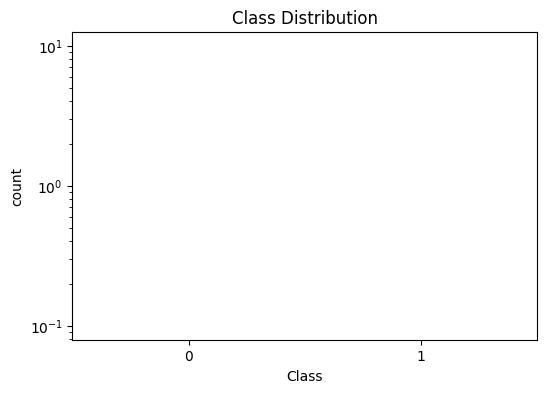

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_sampled,log_scale=True)
plt.title('Class Distribution')
plt.show()

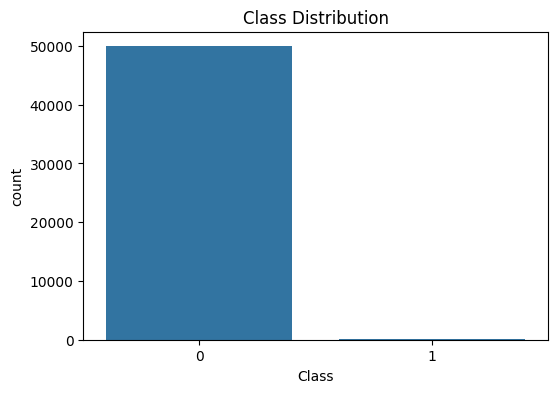

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_sampled)
plt.title('Class Distribution')
plt.show()

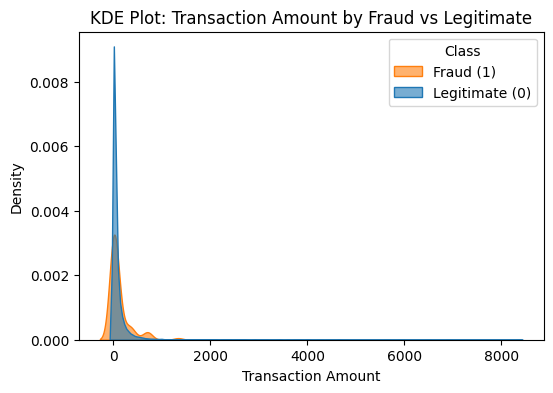

In [33]:

plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_sampled, x='Amount', hue='Class', fill=True, common_norm=False, alpha=0.6)

plt.title('KDE Plot: Transaction Amount by Fraud vs Legitimate')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.legend(title='Class', labels=['Fraud (1)', 'Legitimate (0)'])
plt.show()

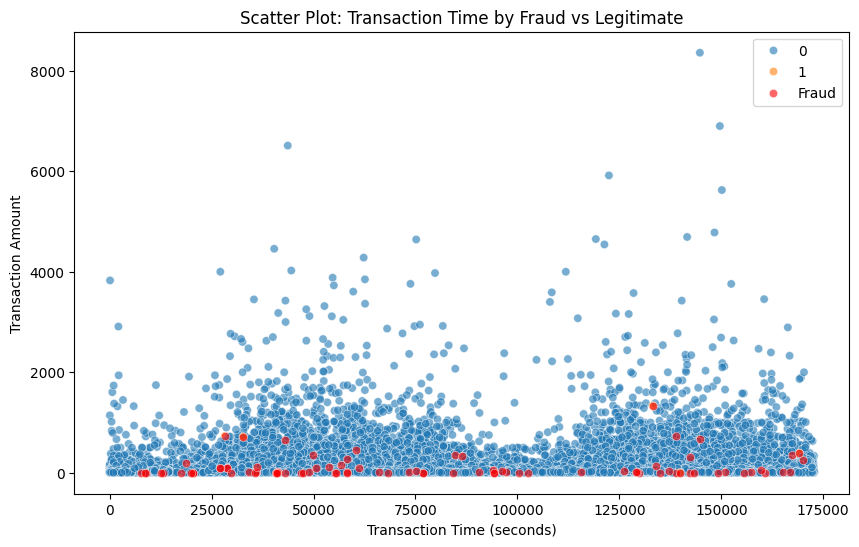

In [34]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sampled, x='Time', y='Amount', hue='Class', alpha=0.6)
sns.scatterplot(data=df_sampled[df_sampled['Class'] == 1], x='Time', y='Amount', color='red', label='Fraud', alpha=0.6)
plt.title('Scatter Plot: Transaction Time by Fraud vs Legitimate')
plt.xlabel('Transaction Time (seconds)')
plt.ylabel('Transaction Amount')
plt.show()

In [35]:
df_sampled.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

KeyboardInterrupt: 

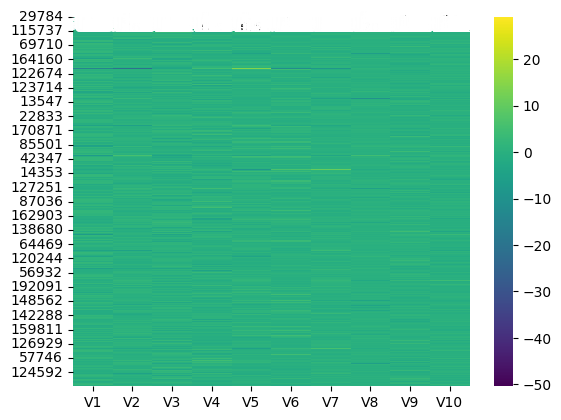

In [39]:
selected_cols = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']  

sns.heatmap(df_sampled[selected_cols], annot=True, cmap='viridis')
plt.show()